# 05 - Customer churn prediction (classification)
**Question:** which customers will not order again in the next 60 days?

**Design:** strict temporal split (features before a cutoff, label after it) so nothing from the future leaks into the features; imbalance handled with class weights; judged on ROC-AUC / PR-AUC against an *everyone-churns* baseline.

PRD target F1 >= 0.70 - read the baseline row before interpreting any F1.

In [1]:
import json, pathlib, pickle, time, sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
CLEAN, IMG, MODELS = ROOT / "data" / "cleaned", ROOT / "images", ROOT / "models"
IMG.mkdir(exist_ok=True); MODELS.mkdir(exist_ok=True); SEED = 42

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier as _SKGB
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
    from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score)
    from sklearn.utils.class_weight import compute_sample_weight
    import sklearn; BACKEND = f"scikit-learn {sklearn.__version__}"
    class GradientBoostingClassifier(_SKGB):          # sklearn's GB has no class_weight -> add it via sample weights
        def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_leaf=1, class_weight=None, random_state=None):
            super().__init__(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=random_state)
            self.class_weight = class_weight
        def fit(self, X, y, sample_weight=None):
            if self.class_weight == "balanced": sample_weight = compute_sample_weight("balanced", y)
            return super().fit(X, y, sample_weight=sample_weight)
except ImportError:
    sys.path.insert(0, str(ROOT))
    from src.mini_sklearn import (LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier, StandardScaler, train_test_split, cross_val_score,
                                  RandomizedSearchCV, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score)
    BACKEND = "mini_sklearn (NumPy fallback)"
print("backend:", BACKEND)

backend: mini_sklearn (NumPy fallback)


## 1. Customer table with a leak-free label

In [2]:
# ---- Label design (the part most churn projects get wrong) ----
# cutoff = last order date - 60 days. Features use ONLY orders on/before the cutoff.
# Label  churn = 1 if the customer places NO order in the 60 days AFTER the cutoff.
abt = pd.read_csv(CLEAN / "analytical_base_table.csv", parse_dates=["OrderDate"]); cust = pd.read_csv(CLEAN / "customers.csv", parse_dates=["RegistrationDate"]).set_index("CustomerID")
HORIZON = 60; cutoff = abt.OrderDate.max() - pd.Timedelta(days=HORIZON)
hist = abt[abt.OrderDate <= cutoff]; fut = abt[(abt.OrderDate > cutoff) & (abt.OrderDate <= cutoff + pd.Timedelta(days=HORIZON))]
g = hist.groupby("CustomerID")
f = pd.DataFrame({"Recency": (cutoff - g.OrderDate.max()).dt.days, "Frequency": g.OrderID.count(), "Monetary": g.FinalAmount.sum(), "AvgOrderValue": g.FinalAmount.mean(),
                  "CancelRate": g.IsCancelled.mean(), "LateRate": g.IsLate.mean(), "CouponRate": g.HasCoupon.mean(), "AvgDeliveryTime": g.DeliveryTimeMinutes.mean(),
                  "AvgRating": g.AvgRating.mean(), "DistinctRestaurants": g.RestaurantID.nunique(), "WeekendShare": g.WeekendOrder.mean(), "FirstOrderAgeDays": (cutoff - g.OrderDate.min()).dt.days})
f["AvgGapDays"] = ((f.FirstOrderAgeDays - f.Recency) / (f.Frequency - 1).replace(0, np.nan)).fillna(-1)       # -1 = single-order customer
f["Tenure"] = (cutoff - cust.RegistrationDate.reindex(f.index)).dt.days; f["Age"] = cust.Age.reindex(f.index)
f["Membership"] = cust.Membership.reindex(f.index); f["PreferredCuisine"] = cust.PreferredCuisine.reindex(f.index)
f["AvgRating"] = f.AvgRating.fillna(f.AvgRating.median()); f["AvgDeliveryTime"] = f.AvgDeliveryTime.fillna(f.AvgDeliveryTime.median())
f["Churn"] = (~f.index.isin(fut.CustomerID.unique())).astype(int); ch = f.reset_index()
print(f"cutoff {cutoff.date()} | customers {len(ch):,} | churn rate {ch.Churn.mean():.1%}")
ch.head(3)

cutoff 2024-11-01 | customers 9,498 | churn rate 87.0%


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,CancelRate,LateRate,CouponRate,AvgDeliveryTime,AvgRating,DistinctRestaurants,WeekendShare,FirstOrderAgeDays,AvgGapDays,Tenure,Age,Membership,PreferredCuisine,Churn
0,1,556,1,744.50,744.500,1.0,0.0,0.0,14.0,3.666667,1,0.0,556,-1.0,874,35,Basic,Fast Food,1
1,2,214,2,810.95,405.475,0.0,0.0,0.5,31.5,4.833333,2,0.0,473,259.0,257,29,Zomato Pro,Mughlai,1
2,3,19,2,966.50,483.250,0.0,0.5,0.5,56.5,4.166667,2,1.0,27,8.0,534,26,Gold,Mughlai,1


## 2. Split, imbalance and baseline

In [3]:
# ---- Imbalance: ~87% churn. Accuracy is meaningless here, so we report ROC-AUC / PR-AUC and the F1 of "everyone churns". ----
NUMERIC = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "CancelRate", "LateRate", "CouponRate", "AvgDeliveryTime", "AvgRating", "DistinctRestaurants", "WeekendShare", "FirstOrderAgeDays", "AvgGapDays", "Tenure", "Age"]
X = pd.get_dummies(ch[NUMERIC + ["Membership"]], columns=["Membership"], dtype=float); y = ch.Churn.values
idx = np.arange(len(X)); itr, ite = train_test_split(idx, test_size=0.2, random_state=SEED, stratify=y)
Xtr, Xte, ytr, yte = X.iloc[itr], X.iloc[ite], y[itr], y[ite]; sc = StandardScaler().fit(Xtr)
def metrics(y, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return dict(Accuracy=accuracy_score(y, pred), Precision=precision_score(y, pred), Recall=recall_score(y, pred), F1=f1_score(y, pred), F1_retained=f1_score(1 - y, 1 - pred),
                ROC_AUC=roc_auc_score(y, proba), PR_AUC=average_precision_score(y, proba))
rows = [dict(Model="Baseline: predict everyone churns", CV_AUC=0.5, Stage="baseline", **metrics(yte, np.ones(len(yte))))]; rows[0]["ROC_AUC"] = 0.5; rows[0]["PR_AUC"] = yte.mean()
pd.DataFrame(rows).round(3)

,Model,CV_AUC,Stage,Accuracy,Precision,Recall,F1,F1_retained,ROC_AUC,PR_AUC
0,Baseline: predict everyone churns,0.5,baseline,0.871,0.871,1.0,0.931,0,0.5,0.871


## 3. Four classifiers (5-fold CV AUC)

In [4]:
# class_weight="balanced" re-weights the rare class (retained customers) - chosen over SMOTE because it adds no synthetic customers
class Scaled:
    def __init__(s, m): s.m = m
    def fit(s, A, b): s.m.fit(sc.transform(A), b); return s
    def predict_proba(s, A): return s.m.predict_proba(sc.transform(A))
    def predict(s, A): return s.m.predict(sc.transform(A))
models = {"Logistic Regression": Scaled(LogisticRegression(C=1.0, class_weight="balanced", max_iter=200)),
          "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, class_weight="balanced", random_state=SEED),
          "Random Forest": RandomForestClassifier(n_estimators=60, max_depth=8, min_samples_leaf=30, class_weight="balanced", random_state=SEED),
          "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_samples_leaf=30, class_weight="balanced", random_state=SEED)}
fitted, probas = {}, {}
for name, m in models.items():
    t = time.time()
    if name == "Logistic Regression":
        cv = cross_val_score(LogisticRegression(C=1.0, class_weight="balanced", max_iter=200), sc.transform(Xtr), ytr, cv=5, scoring="roc_auc")
    else:
        cv = cross_val_score(m, Xtr.values, ytr, cv=5, scoring="roc_auc")
    m.fit(Xtr.values, ytr); fitted[name] = m; probas[name] = m.predict_proba(Xte.values)[:, 1]
    rows.append(dict(Model=name, CV_AUC=cv.mean(), Stage="default", **metrics(yte, probas[name]))); print(f"{name:20s} CV AUC {cv.mean():.4f}  test AUC {rows[-1]['ROC_AUC']:.4f}  F1 {rows[-1]['F1']:.4f}  ({time.time() - t:.0f}s)")
pd.DataFrame(rows).round(4)

Logistic Regression  CV AUC 0.4995  test AUC 0.5249  F1 0.6627  (0s)
Decision Tree        CV AUC 0.5063  test AUC 0.5154  F1 0.4370  (0s)
Random Forest        CV AUC 0.4948  test AUC 0.5142  F1 0.8610  (5s)
Gradient Boosting    CV AUC 0.4988  test AUC 0.5130  F1 0.7126  (3s)


,Model,CV_AUC,Stage,Accuracy,Precision,Recall,F1,F1_retained,ROC_AUC,PR_AUC
0,Baseline: predict everyone churns,0.5000,baseline,0.8705,0.8705,1.0000,0.9308,0.0000,0.5000,0.8705
1,Logistic Regression,0.4995,default,0.5284,0.8782,0.5320,0.6627,0.2168,0.5249,0.8853
2,Decision Tree,0.5063,default,0.3463,0.8732,0.2914,0.4370,0.2208,0.5154,0.8719
3,Random Forest,0.4948,default,0.7611,0.8722,0.8501,0.8610,0.1498,0.5142,0.8754
4,Gradient Boosting,0.4988,default,0.5758,0.8687,0.6040,0.7126,0.1908,0.5130,0.8804


## 4. Tuning and selection

In [5]:
grids = {"Random Forest": (RandomForestClassifier(class_weight="balanced", random_state=SEED), {"n_estimators": [40, 60], "max_depth": [4, 6, 8], "min_samples_leaf": [30, 60, 120], "max_features": ["sqrt", 0.5]}),
         "Gradient Boosting": (GradientBoostingClassifier(class_weight="balanced", random_state=SEED), {"n_estimators": [50, 100, 150], "learning_rate": [0.02, 0.05, 0.1], "max_depth": [2, 3], "min_samples_leaf": [30, 80]}),
         "Decision Tree": (DecisionTreeClassifier(class_weight="balanced", random_state=SEED), {"max_depth": [3, 4, 5, 7], "min_samples_leaf": [30, 60, 120]})}
d0 = pd.DataFrame(rows[1:]); top2 = d0[d0.Model.isin(list(grids))].sort_values("CV_AUC", ascending=False).Model.head(2).tolist(); tuned = {}
for name in top2:
    est, grid = grids[name]; s = RandomizedSearchCV(est, grid, n_iter=4, cv=3, scoring="roc_auc", random_state=SEED).fit(Xtr.values, ytr)
    pr = s.best_estimator_.predict_proba(Xte.values)[:, 1]; tuned[name + " (tuned)"] = s.best_estimator_; probas[name + " (tuned)"] = pr
    rows.append(dict(Model=name + " (tuned)", CV_AUC=s.best_score_, Stage="tuned", Params=str(s.best_params_), **metrics(yte, pr))); print(name, s.best_params_, f"CV AUC {s.best_score_:.4f}")
res = pd.DataFrame(rows)
sel = res[res.Stage != "baseline"].sort_values("CV_AUC", ascending=False).iloc[0]       # selection by CV, not test
best_name = sel.Model; best = tuned.get(best_name, fitted.get(best_name)); pr = probas[best_name]; is_lin = best_name == "Logistic Regression"
print("selected by CV AUC:", best_name); res.round(4)[["Model", "Stage", "CV_AUC", "Accuracy", "F1", "F1_retained", "ROC_AUC", "PR_AUC"]]

Decision Tree {'max_depth': 3, 'min_samples_leaf': 30} CV AUC 0.5025
Gradient Boosting {'n_estimators': 100, 'learning_rate': 0.02, 'max_depth': 2, 'min_samples_leaf': 80} CV AUC 0.5192
selected by CV AUC: Gradient Boosting (tuned)


,Model,Stage,CV_AUC,Accuracy,F1,F1_retained,ROC_AUC,PR_AUC
0,Baseline: predict everyone churns,baseline,0.5000,0.8705,0.9308,0.0000,0.5000,0.8705
1,Logistic Regression,default,0.4995,0.5284,0.6627,0.2168,0.5249,0.8853
2,Decision Tree,default,0.5063,0.3463,0.4370,0.2208,0.5154,0.8719
3,Random Forest,default,0.4948,0.7611,0.8610,0.1498,0.5142,0.8754
4,Gradient Boosting,default,0.4988,0.5758,0.7126,0.1908,0.5130,0.8804
5,Decision Tree (tuned),tuned,0.5025,0.6668,0.7885,0.2156,0.5268,0.8815
6,Gradient Boosting (tuned),tuned,0.5192,0.5753,0.7083,0.2188,0.5301,0.8865


## 5. Drivers and significance

In [6]:
# ---- Drivers (permutation AUC drop on test) + is the AUC distinguishable from chance? ----
def permutation_auc(model, X, y, n_repeats=5, seed=SEED):
    rng = np.random.RandomState(seed); Xv = X.values.copy(); base = roc_auc_score(y, model.predict_proba(Xv)[:, 1]); out = []
    for j in range(Xv.shape[1]):
        dd = []
        for _ in range(n_repeats):
            col = Xv[:, j].copy(); Xv[:, j] = rng.permutation(col); dd.append(base - roc_auc_score(y, model.predict_proba(Xv)[:, 1])); Xv[:, j] = col
        out.append(np.mean(dd))
    return pd.Series(out, index=X.columns)
imp = pd.DataFrame({"feature": X.columns, "auc_drop_when_shuffled": permutation_auc(best, Xte, yte).values}).sort_values("auc_drop_when_shuffled", ascending=False)
rng = np.random.RandomState(1); null = [roc_auc_score(rng.permutation(yte), pr) for _ in range(500)]
print(f"test AUC {roc_auc_score(yte, pr):.3f} | AUC under random labels: mean {np.mean(null):.3f}, 95th pct {np.percentile(null, 95):.3f}")
print("p-value (share of random AUCs >= observed):", np.mean(np.array(null) >= roc_auc_score(yte, pr))); imp.head(8).round(4)

test AUC 0.530 | AUC under random labels: mean 0.502, 95th pct 0.534
p-value (share of random AUCs >= observed): 0.082


,feature,auc_drop_when_shuffled
13,Tenure,0.0091
14,Age,0.0048
11,FirstOrderAgeDays,0.0022
2,Monetary,0.0009
1,Frequency,0.0000
15,Membership_Basic,0.0000
6,CouponRate,0.0000
12,AvgGapDays,0.0000


## 6. Scoring and risk segments

In [7]:
# ---- Score every customer and build risk segments (terciles of predicted probability) ----
allp = best.predict_proba(X.values)[:, 1]
sc_df = ch[["CustomerID", "Recency", "Frequency", "Monetary", "Churn"]].copy(); sc_df["ChurnProbability"] = allp
sc_df["Split"] = "train"; sc_df.loc[sc_df.index[ite], "Split"] = "test"
q = sc_df.ChurnProbability.quantile([.33, .66]).values
sc_df["RiskSegment"] = np.where(sc_df.ChurnProbability >= q[1], "High", np.where(sc_df.ChurnProbability >= q[0], "Medium", "Low"))
print("actual churn rate by segment (TEST customers only - the honest view):")
(sc_df[sc_df.Split == "test"].groupby("RiskSegment").Churn.agg(["mean", "count"]).reindex(["Low", "Medium", "High"]).round(3))

actual churn rate by segment (TEST customers only - the honest view):


,mean,count
RiskSegment,,
Low,0.850,625
Medium,0.880,643
High,0.881,632


## 7. Save and plot

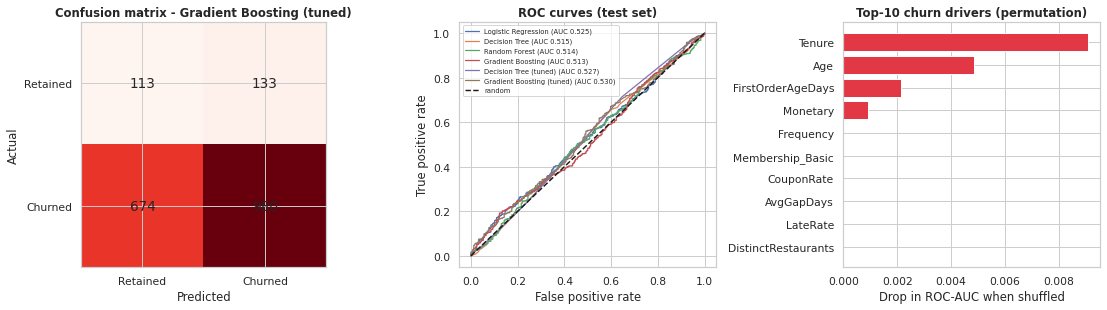

In [8]:
res.to_csv(CLEAN / "model_comparison_churn.csv", index=False); imp.to_csv(CLEAN / "feature_importance_churn.csv", index=False)
sc_df.to_csv(CLEAN / "churn_scores.csv", index=False); ch.to_csv(CLEAN / "churn_features.csv", index=False)
with open(MODELS / "churn_best_model.pkl", "wb") as fh:
    pickle.dump(dict(model=best, name=best_name, features=list(X.columns), scaler=sc if is_lin else None, cutoff=str(cutoff.date()), backend=BACKEND, test_metrics=metrics(yte, pr)), fh)
(REP := ROOT / "reports").mkdir(exist_ok=True)
cm = confusion_matrix(yte, (pr >= .5).astype(int)); fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
ax[0].imshow(cm, cmap="Reds"); [ax[0].text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=14) for i in range(2) for j in range(2)]
ax[0].set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"], xlabel="Predicted", ylabel="Actual", title=f"Confusion matrix - {best_name}")
for n, p in probas.items():
    fpr, tpr, _ = roc_curve(yte, p); ax[1].plot(fpr, tpr, label=f"{n} (AUC {roc_auc_score(yte, p):.3f})", lw=1.3)
ax[1].plot([0, 1], [0, 1], "k--", label="random"); ax[1].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curves (test set)"); ax[1].legend(fontsize=7)
t10 = imp.head(10).iloc[::-1]; ax[2].barh(t10.feature, t10.auc_drop_when_shuffled, color="#E23744"); ax[2].set(xlabel="Drop in ROC-AUC when shuffled", title="Top-10 churn drivers (permutation)")
plt.tight_layout(); plt.savefig(IMG / "ml_churn_evaluation.png", dpi=130)

## Conclusion
* With ~87% of customers churning, a model that predicts *everyone churns* already gets F1 around 0.93 on the churn class, so a raw F1 of 0.70 would be **worse** than doing nothing. Use ROC-AUC, PR-AUC and segment lift instead.
* The best test ROC-AUC is only slightly above 0.5 and is close to what random labels produce (section 5), so the model has little real predictive power; risk segments do not separate churn rates meaningfully (section 6).
* Likely cause: most customers have 1-2 orders, so there is little behavioural history to learn from. More history, app-engagement events and campaign exposure would be needed.
* Before deploying anything: re-run on a later cutoff (out-of-time validation) and check calibration.